## 🌲 ¿Qué es un Random Forest?

`RandomForestClassifier` es un algoritmo de **aprendizaje supervisado** que pertenece a los modelos de **ensemble**. Utiliza múltiples **árboles de decisión** para mejorar la precisión del modelo y reducir el sobreajuste (**overfitting**).

---

### 🔧 ¿Cómo funciona?

1. Crea muchos árboles de decisión (cada uno con un subconjunto distinto de los datos y características).
2. Cada árbol hace su predicción de manera independiente.
3. El modelo final **vota** por la clase más frecuente (en clasificación) o **promedia** los resultados (en regresión).

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = sns.load_dataset('titanic').dropna()
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
10,1,3,female,4.0,1,1,16.7000,S,Third,child,False,G,Southampton,yes,False
11,1,1,female,58.0,0,0,26.5500,S,First,woman,False,C,Southampton,yes,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
871,1,1,female,47.0,1,1,52.5542,S,First,woman,False,D,Southampton,yes,False
872,0,1,male,33.0,0,0,5.0000,S,First,man,True,B,Southampton,no,True
879,1,1,female,56.0,0,1,83.1583,C,First,woman,False,C,Cherbourg,yes,False
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True


# MODELO DE CLASIFICACIÓN CON RANDOM FOREST

## PASO 1 IDENFITICAR VARIABLE X Y Y

In [4]:
cols = ['pclass','sex','age','sibsp','parch','fare','embarked']
target = 'survived'
X = df[cols]
y = df[target]

In [5]:
X.dtypes

,0
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object


In [6]:
X = pd.get_dummies(X,columns=['sex','embarked'],drop_first=True)

 ## PASO 2 DIVIDIR DATASET EN ENTRENAMIENTO Y PRUEBA

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

## PASO 3 - ENTRENAMIENTO DEL MODELO

In [9]:
model = RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

## PASO 4 - EVALUAMOS EL MODELO

In [10]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
print(f'Accuracy : {accuracy:.2f}')

Accuracy : 0.76


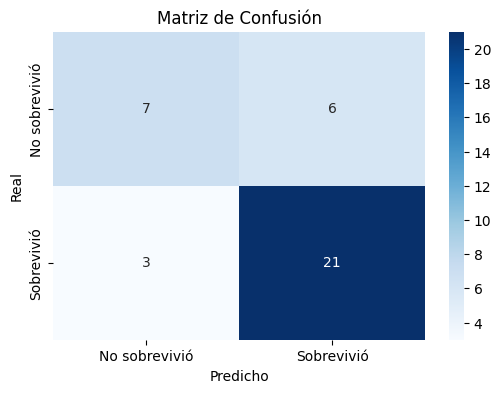

In [11]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No sobrevivió', 'Sobrevivió'], yticklabels=['No sobrevivió', 'Sobrevivió'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()